In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import glob
import functools
from hyppo.ksample import Hotelling
import logging
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import quantities as pq
import scipy.stats as stats

import epych
from epych.statistics import alignment

[striatum:365059] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/3001221120/shared_mem_cuda_pool.striatum could be created.
[striatum:365059] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
CONDITIONS = ["go_gloexp", "go_seqctl", "lo_gloexp", "lonaive", "lo_rndctl", "igo_seqctl", "go_rndctl"]
PRETRIAL_SECONDS = 0.5
POSTTRIAL_SECONDS = 0.5
FORCE_RECOMPUTE = False
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [7]:
NWB_SUBJECTS = glob.glob('/mnt/data/000253/sub-*/')

In [8]:
PILOT_FILES = []

In [9]:
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.020) * pq.second

In [10]:
aligner = epych.statistics.alignment.AlignmentSummary.unpickle("/mnt/data/000253/visual_alignment")
AREA_COUNTER = collections.Counter()

In [11]:
def visual_align(signal):
    visual = signal.select_channels(["VIS" in loc for loc in signal.channels.location]).median_filter()
    area = alignment.location_prefix(None, visual)
    result = aligner.stats[area].align(AREA_COUNTER[area], visual)
    AREA_COUNTER[area] += 1
    return result

In [12]:
def samplings(s, subject_dir, cond):
    subject = subject_dir.split('/')[-2]
    sampling = epych.recording.Sampling.unpickle(subject_dir + "/" + cond).smap(
        lambda sig: visual_align(sig)[(ODDBALL_ONSET - OFFSET).magnitude:(ODDBALL_OFFSET + OFFSET).magnitude]
    )
    logging.info("Loaded LFPs for %s in subject %s" % (cond, subject))
    yield sampling
    del sampling

In [13]:
def initialize_spectrum(key, signal):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.PowerSpectrum(signal.df, signal.channels, signal.f0, taper="hann", time_window=0.500)

In [14]:
summaries = {cond: {} for cond in CONDITIONS}

In [15]:
for cond in CONDITIONS:
    global AREA_COUNTER
    AREA_COUNTER = collections.Counter()
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        if not os.path.exists(subject_dir + "/" + cond):
            continue
        if os.path.exists("/mnt/data/000253/%s/spectrum_%s" % (subject_dir, cond)) and not FORCE_RECOMPUTE:
            summaries[cond][subject] = epych.statistic.Summary.unpickle("/mnt/data/000253/%s/spectrum_%s" % (subject_dir, cond),
                                                                        epych.statistics.spectrum.PowerSpectrum)
        else:
            summaries[cond][subject] = epych.statistic.Summary(alignment.location_prefix, initialize_spectrum)
            summaries[cond][subject].calculate(samplings(s, subject_dir, cond))
            summaries[cond][subject].pickle("/mnt/data/000253/%s/spectrum_%s" % (subject_dir, cond))
        logging.info("Analyzed spectra from %s LFPs in subject %s" % (cond, subject))

INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-621890
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-632485
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-632487
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-637542
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-637908
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-637909
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-640507
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-642507
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-645322
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-645324
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-645495
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-647836
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-649323
INFO:root:Analyzed spectra from go_gloexp LFPs in subject sub-649324
INFO:root:Analyzed spectra from go

In [16]:
aperiodic_params = {cond: {area: [] for area in anatomical_areas} for cond in CONDITIONS}

for cond in CONDITIONS:
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        for area in summaries[cond][subject].stats:
            if area not in anatomical_areas:
                continue
            aperiodic_params[cond][area].append(summaries[cond][subject].stats[area].aperiodic_parameters(channel_mean=True))
    for area in anatomical_areas:
        aperiodic_params[cond][area] = np.stack(aperiodic_params[cond][area], axis=0).squeeze()

In [17]:
CONTRASTS = [("dd", "lo_rndctl", "lonaive"), ("go_contrast", "go_gloexp", "go_seqctl"), ("ssa", "lo_gloexp", "igo_seqctl"), ("control", "go_rndctl", "go_seqctl")]
contrast_results = {name: {area: None for area in anatomical_areas} for (name, _, _) in CONTRASTS}

In [18]:
for name, condl, condr in CONTRASTS:
    for area in anatomical_areas:
        contrast_results[name][area] = stats.ttest_ind(aperiodic_params[condl][area], aperiodic_params[condr][area], equal_var=False, method=stats.PermutationMethod(n_resamples=1000))

In [19]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("t-test results for %s contrast in area %s: %s" % (name, area, str(contrast_results[name][area])))

INFO:root:t-test results for dd contrast in area VISp: TtestResult(statistic=array([0.5607, 0.361 ]), pvalue=array([0.5814, 0.6793]), df=array([25.8409, 25.9519]))
INFO:root:t-test results for dd contrast in area VISl: TtestResult(statistic=array([ 0.0048, -0.3342]), pvalue=array([0.995 , 0.7193]), df=array([23.8068, 23.9957]))
INFO:root:t-test results for dd contrast in area VISrl: TtestResult(statistic=array([ 0.1731, -0.2345]), pvalue=array([0.8951, 0.7912]), df=array([25.4465, 25.5918]))
INFO:root:t-test results for dd contrast in area VISal: TtestResult(statistic=array([ 0.2225, -0.0053]), pvalue=array([0.8052, 0.965 ]), df=array([18.0222, 19.6577]))
INFO:root:t-test results for dd contrast in area VISpm: TtestResult(statistic=array([0.2408, 0.023 ]), pvalue=array([0.8212, 0.989 ]), df=array([25.9139, 25.6032]))
INFO:root:t-test results for dd contrast in area VISam: TtestResult(statistic=array([0.5983, 0.4642]), pvalue=array([0.5654, 0.6454]), df=array([25.061 , 25.7027]))
INFO:r

In [20]:
fits = {cond: {area: [] for area in anatomical_areas} for cond in CONDITIONS}

for cond in CONDITIONS:
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        for area in summaries[cond][subject].stats:
            if area not in anatomical_areas:
                continue
            fits[cond][area].append(summaries[cond][subject].stats[area].fooofed(channel_mean=True, space="log", report=False)[-1])

In [21]:
for area in anatomical_areas:
    nfreqs = []
    for cond in CONDITIONS:
        nfreqs.append([fit.shape[0] for fit in fits[cond][area]])
    nfreqs = np.array(nfreqs).min()
    for cond in CONDITIONS:
        fits[cond][area] = [fit[:nfreqs] for fit in fits[cond][area]]
        fits[cond][area] = np.stack(fits[cond][area], axis=0).squeeze()

In [22]:
contrast_results = {name: {area: None for area in anatomical_areas} for (name, _, _) in CONTRASTS}

In [23]:
for name, condl, condr in CONTRASTS:
    for area in anatomical_areas:
        contrast_results[name][area] = stats.ttest_ind(fits[condl][area], fits[condr][area], equal_var=False, method=stats.PermutationMethod(n_resamples=1000))

In [24]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("Permutation-based t-test results for %s contrast in area %s, α=0.05: %s" % (name, area, (contrast_results[name][area].pvalue < 0.05).any()))
        logging.info("Permutation-based t-test results for %s contrast in area %s, α=0.01: %s" % (name, area, (contrast_results[name][area].pvalue < 0.01).any()))

INFO:root:Permutation-based t-test results for dd contrast in area VISp, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISp, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISl, α=0.05: False
INFO:root:Permutation-based t-test results for dd contrast in area VISl, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISrl, α=0.05: False
INFO:root:Permutation-based t-test results for dd contrast in area VISrl, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISal, α=0.05: False
INFO:root:Permutation-based t-test results for dd contrast in area VISal, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISpm, α=0.05: False
INFO:root:Permutation-based t-test results for dd contrast in area VISpm, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISam, α=0.05: False
INFO:root:Permutation-based t-test re

In [25]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("t-test results for %s contrast in area %s: %s" % (name, area, str(contrast_results[name][area])))

INFO:root:t-test results for dd contrast in area VISp: TtestResult(statistic=array([ 0.5315,  0.331 ,  0.1775,  1.5628,  1.4281,  0.8872,  0.7079,  0.4643,
        0.0055, -0.4143, -0.6134, -0.7393, -0.7218, -0.7028, -0.7487, -0.4788,
        0.2361,  0.9839,  2.0452,  2.8606,  2.7682,  1.9216,  1.4534,  1.1466,
        0.8591,  0.5907,  0.533 ,  0.5395,  0.3985,  0.2565,  0.193 ,  0.0592,
        0.1197,  0.1097,  0.2111,  0.3095,  0.474 ,  0.5956,  0.6557,  0.665 ,
        0.5784,  0.4329,  0.337 ,  0.3042,  0.2407,  0.2052,  0.2198,  0.1728,
        0.2321,  0.261 ,  0.0615,  0.0256,  0.088 ,  0.0708,  0.0583,  0.0451,
        0.0245, -0.0056, -0.0314, -0.033 , -0.0114,  0.0126,  0.0252,  0.0281,
        0.0273,  0.0256,  0.0239,  0.0221,  0.0204,  0.0187,  0.0171,  0.0155,
        0.0139,  0.0124,  0.0109]), pvalue=array([0.5834, 0.7053, 0.8072, 0.1399, 0.1738, 0.3836, 0.4675, 0.6114, 0.967 ,
       0.7013, 0.5554, 0.4735, 0.4895, 0.4875, 0.4755, 0.6513, 0.7992, 0.2997,
       0.05

In [26]:
aperiodics = {cond: {subject: {area: None for area in summaries[cond][subject].stats} for subject in summaries[cond]} for cond in CONDITIONS}
oscillatories = {cond: {subject: {area: None for area in summaries[cond][subject].stats} for subject in summaries[cond]} for cond in CONDITIONS}
peaks = {cond: {subject: {area: None for area in summaries[cond][subject].stats} for subject in summaries[cond]} for cond in CONDITIONS}

In [27]:
for cond in CONDITIONS:
    for subject in summaries[cond]:
        for area in summaries[cond][subject].stats:
            oscillatory, _, aperiodic = summaries[cond][subject].stats[area].oscillatory(space="log")
            aperiodics[cond][subject][area] = np.power(10, aperiodic)
            oscillatories[cond][subject][area] = oscillatory
            peaks[cond][subject][area] = summaries[cond][subject].stats[area].peaks(channel_mean=True)
            logging.info("Separated aperiodic and oscillatory components of spectrum for condition %s, subject %s, area %s" % (cond, subject, area))

INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-621890, area VISam
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-621890, area VISl
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-621890, area VISp
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-621890, area VISpm
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-621890, area VISrl
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-632485, area VISam
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-632485, area VISl
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, subject sub-632485, area VISp
INFO

In [28]:
from epych import plotting
from epych.statistics import spectrum

In [29]:
AREA_TITLES = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
BANDS = [spectrum.THETA_BAND, spectrum.ALPHA_BETA_BAND, spectrum.GAMMA_BAND]
BAND_BOUNDS = np.unique(list(spectrum.THETA_BAND) +\
                        list(spectrum.ALPHA_BETA_BAND) +\
                        list(spectrum.GAMMA_BAND)) * pq.Hz
CONDITION_TITLES = {
    "lonaive": "Habituation",
    "go_gloexp": "xxxX [B1]",
    "go_rndctl": "XXXX [B2]",
    "go_seqctl": "xxxx [B3]",
    "lo_gloexp": "xxxY [B1]",
    "lo_rndctl": "XXXY [B2]",
    "igo_seqctl": "yyyy [B3]"
}
CONTRAST_TITLES = {
    "go_contrast": "GO",
    "ssa": "SSA",
    "dd": "DD",
    "control": "CTRL"
}

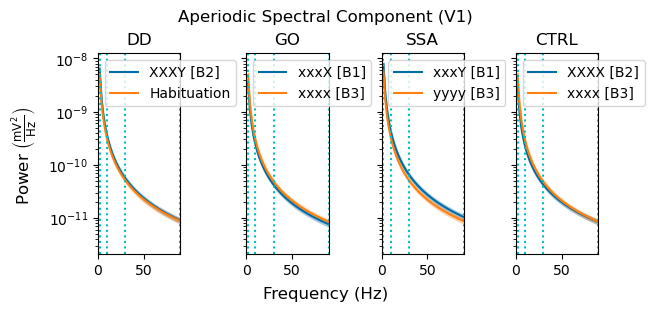

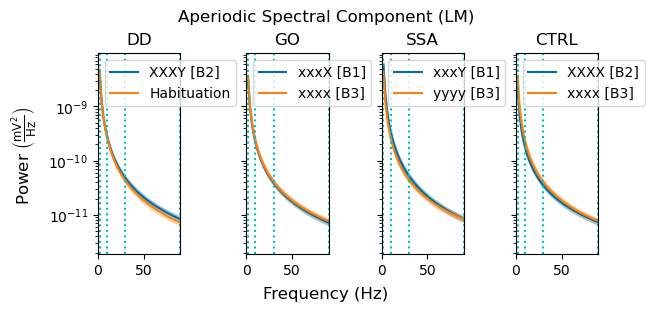

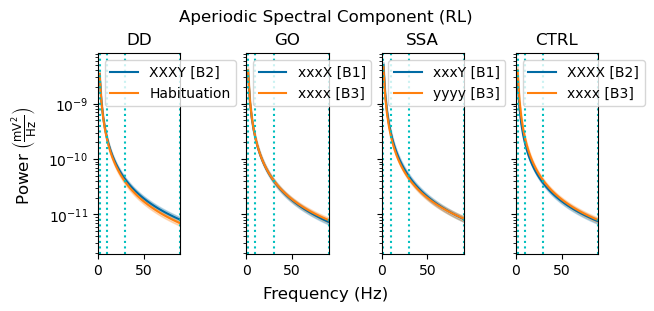

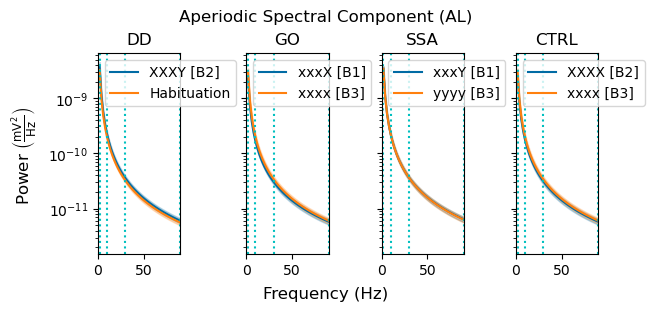

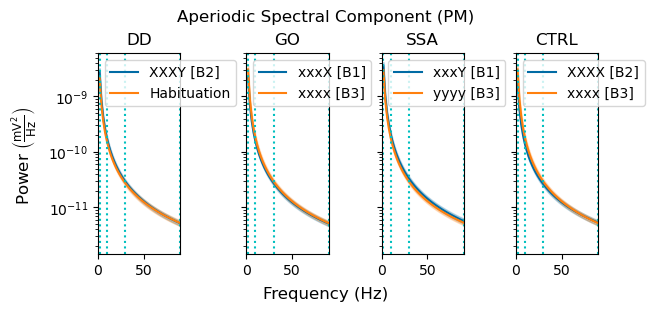

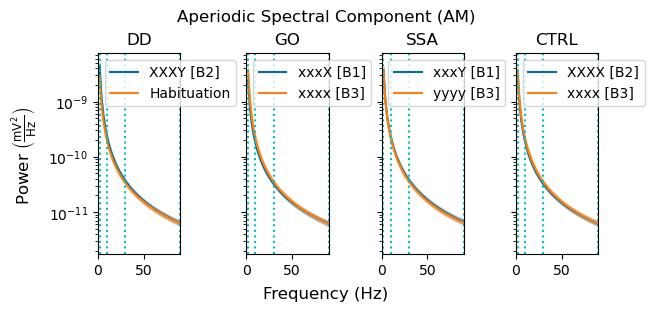

In [30]:
spectrum_trials = collections.defaultdict(lambda: collections.defaultdict(lambda: []))
for cond in CONDITIONS:
    for subject in summaries[cond]:
        for area in oscillatories[cond][subject]:
            spectrum_trials[area][cond].append(aperiodics[cond][subject][area].mean(axis=(0, -1), keepdims=True))
for area in spectrum_trials:
    for cond in spectrum_trials[area]:
        spectrum_trials[area][cond] = np.concatenate(spectrum_trials[area][cond], axis=-1).squeeze()

for area in anatomical_areas:
    plt.style.use('tableau-colorblind10')
    #               DD, GO, SSA
    # Oddball
    # Control
    # Difference
    fig, axes = plt.subplots(nrows=1, ncols=len(CONTRASTS), sharex=True, sharey=True, layout="constrained")
    fig.supxlabel("Frequency (Hz)"); fig.supylabel("Power $\\left(\\frac{\\mathrm{mV}^{2}}{\\mathrm{Hz}}\\right)$")
    fig.suptitle(("Aperiodic Spectral Component (%s)" % AREA_TITLES[area]))
    fig.set_figheight(3)
    for col, (contrast, condl, condr) in enumerate(CONTRASTS):
        axes[col].set_title(CONTRAST_TITLES[contrast])
        plotting.plot_sem(oscillatories[condl][subject][area].freqs.magnitude, spectrum_trials[area][condl], ax=axes[col], axis=-1, sems=2, label=CONDITION_TITLES[condl])
        
        plotting.plot_sem(oscillatories[condr][subject][area].freqs.magnitude, spectrum_trials[area][condr], ax=axes[col], axis=-1, sems=2, label=CONDITION_TITLES[condr])

        for boundary in BAND_BOUNDS:
            axes[col].axvline(boundary, color='c', linestyle=':')
        axes[col].set_xlim([0, 90]); axes[col].set_yscale("log"); # axes[col].set_ylim([10e-12, 10e-8])
        axes[col].legend()

        # band_midpoints = [(low + high) / 2 for (low, high) in zip(BAND_BOUNDS, BAND_BOUNDS[1:])]
        # axes[col].set_xticks(band_midpoints, labels=["$\\theta$", "$\\alpha/\\beta$", "$\\gamma$"])

    plt.savefig("%s_aperiodic_spectra.svg" % AREA_TITLES[area])
    plt.savefig("%s_aperiodic_spectra.png" % AREA_TITLES[area])
    plt.show()

In [31]:
from fooof.sim.gen import gen_periodic
import matplotlib.colors as mcolors

def average_band_peak(cond, area, fmin, fmax):
    subject_peaks = []
    for subject in summaries[cond]:
        peak_params = peaks[cond][subject][area][0]
        band_peaks = np.logical_and(peak_params[0, :, 0] >= fmin.magnitude, peak_params[0, :, 0] <= fmax.magnitude)
        if not band_peaks.any():
            continue
        band_peak = peak_params[:, band_peaks, 1].argmax()
        subject_peaks.append(peak_params[:, band_peak, :])
    subject_peaks = np.concatenate(subject_peaks, axis=0).mean(axis=0)

    return subject_peaks, gen_periodic(summaries[cond][subject].stats[area].freqs.magnitude, subject_peaks)

def band_max(cond, area, fmin, fmax, trial_mean=True):
    freqs, oscillatory = oscillatories[cond][subject][area].freqs, spectrum_trials[area][cond]
    band_freqs = np.logical_and(freqs >= fmin, freqs <= fmax)
    idx = oscillatory[band_freqs].argmax(axis=0)
    if trial_mean:
        return freqs[band_freqs][idx].mean(axis=-1), oscillatory[band_freqs][idx, np.arange(len(idx))].mean(axis=-1)
    return freqs[band_freqs][idx], oscillatory[band_freqs][idx, np.arange(len(idx))]

In [32]:
def peak_ci(cond, area, fpeaks):
    (low, high) = stats.norm.interval(0.99, loc=stats.tmean(fpeaks), scale=stats.sem(fpeaks))
    logging.info("99 percent onfidence interval for peak gamma frequency in condition %s, area %s: (%f, %f)" % (cond, area, low, high))

def band_peak_test(condl, condr, area, fmin, fmax):
    fpeakl, _ = band_max(condl, area, fmin, fmax, trial_mean=False)
    fpeakr, _ = band_max(condr, area, fmin, fmax, trial_mean=False)

    peak_ci(condl, area, fpeakl)
    peak_ci(condr, area, fpeakr)
    
    test = stats.ttest_ind(fpeakl, fpeakr, equal_var=False, method=stats.PermutationMethod(n_resamples=1000))
    if test.pvalue < 0.01:
        return "**"
    elif test.pvalue < 0.05:
        return "*"
    return None

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISp: (35.186027, 40.528258)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISp: (32.580808, 36.847763)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISp: (35.067029, 51.504400)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISp: (34.601178, 51.970251)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISp: (33.773100, 39.084043)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISp: (34.969693, 43.316022)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISp: (38.490408, 57.795307)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISp: (34.601178, 51.970251)


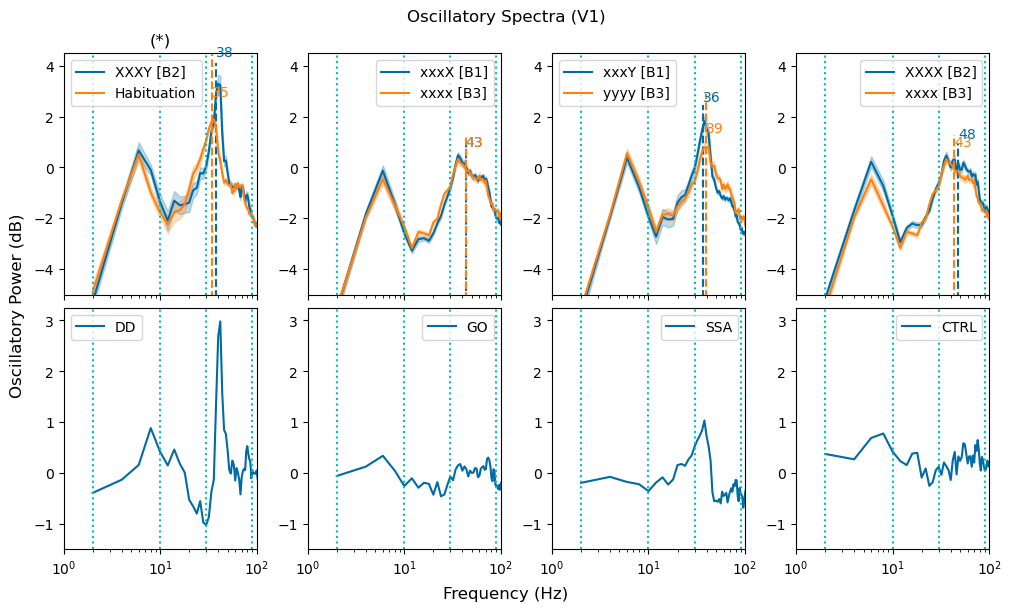

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISl: (35.931354, 46.530185)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISl: (32.816418, 37.952813)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISl: (44.311724, 56.611353)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISl: (41.524479, 56.937059)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISl: (34.858591, 39.602948)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISl: (36.720257, 48.818204)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISl: (39.660866, 52.954518)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISl: (41.524479, 56.937059)


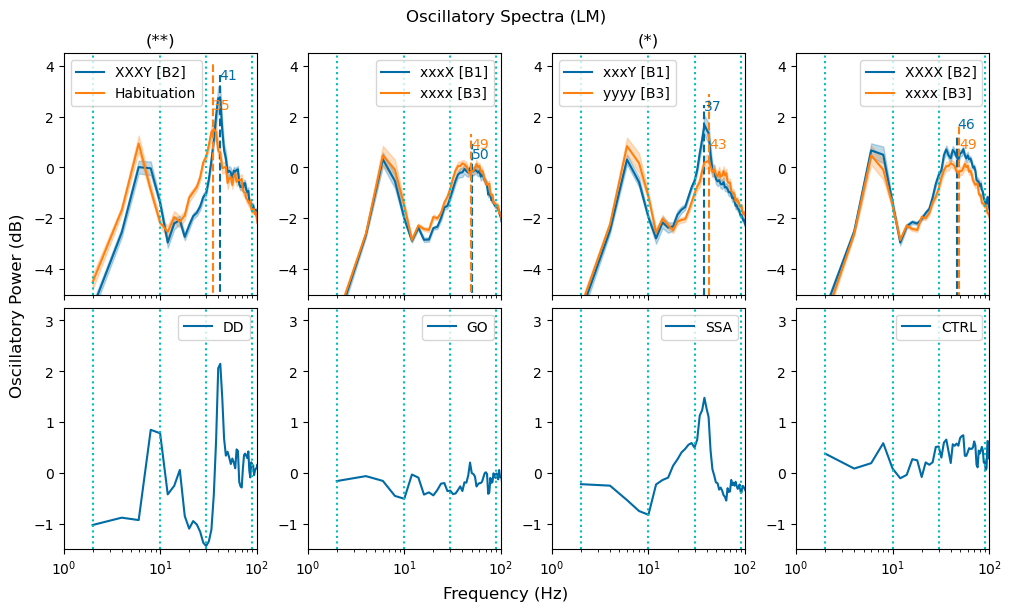

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISrl: (36.324590, 40.532553)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISrl: (32.453544, 40.403599)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISrl: (37.233311, 50.766689)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISrl: (34.991764, 54.722522)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISrl: (34.956195, 39.615233)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISrl: (39.015972, 51.269743)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISrl: (35.869104, 50.702324)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISrl: (34.991764, 54.722522)


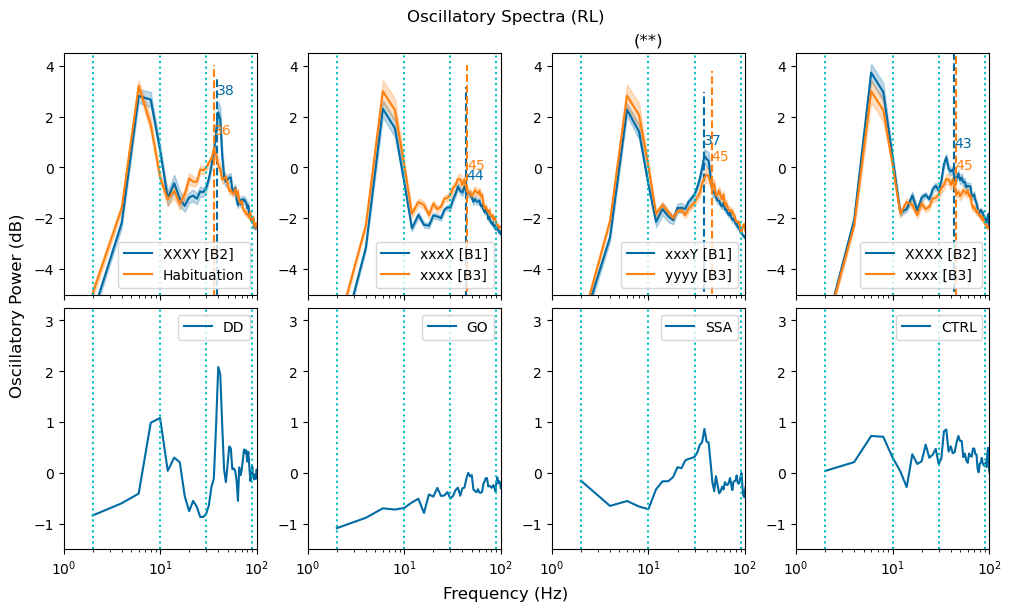

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISal: (34.756039, 40.153052)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISal: (32.186310, 37.631872)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISal: (34.334085, 54.756824)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISal: (39.014270, 61.349366)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISal: (33.689625, 39.037647)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISal: (34.396020, 53.967616)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISal: (33.324303, 47.039333)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISal: (39.014270, 61.349366)


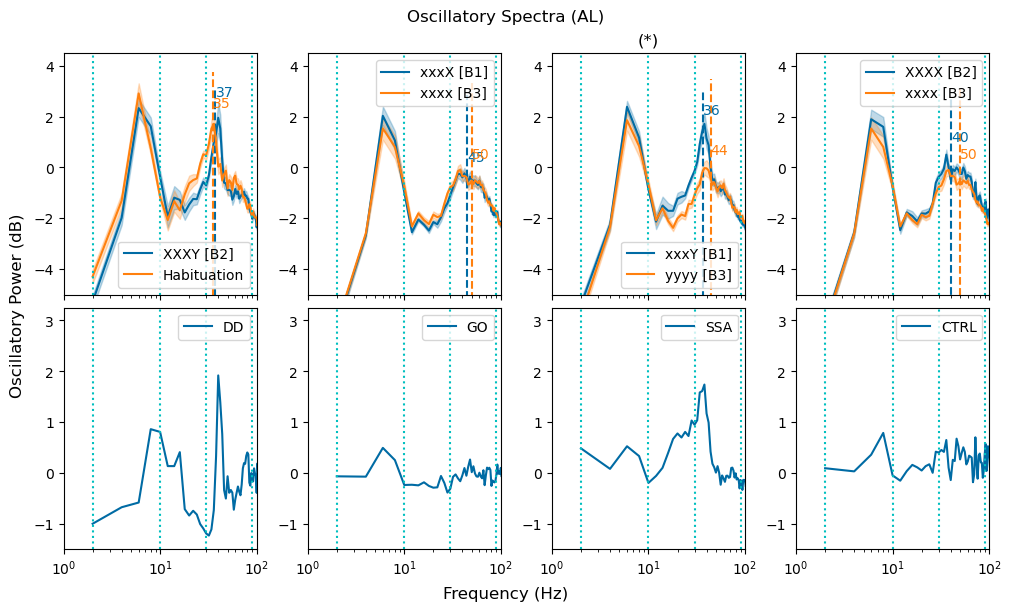

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISpm: (35.837106, 44.734323)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISpm: (34.275542, 46.295886)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISpm: (43.190879, 54.237693)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISpm: (38.631355, 53.654359)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISpm: (34.201728, 44.083986)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISpm: (37.808823, 47.048320)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISpm: (42.360603, 55.353682)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISpm: (38.631355, 53.654359)


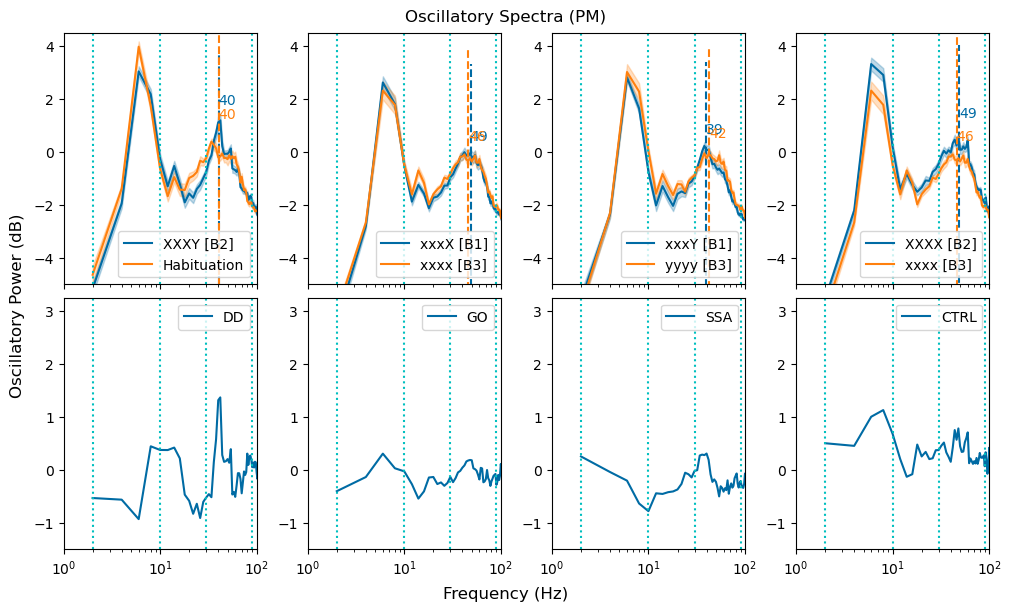

INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_rndctl, area VISam: (35.613174, 41.243969)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lonaive, area VISam: (35.454098, 47.117331)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_gloexp, area VISam: (44.415771, 55.869943)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISam: (40.069941, 56.215773)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition lo_gloexp, area VISam: (34.344706, 41.941008)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition igo_seqctl, area VISam: (38.888766, 54.825519)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_rndctl, area VISam: (45.548501, 58.165785)
INFO:root:99 percent onfidence interval for peak gamma frequency in condition go_seqctl, area VISam: (40.069941, 56.215773)


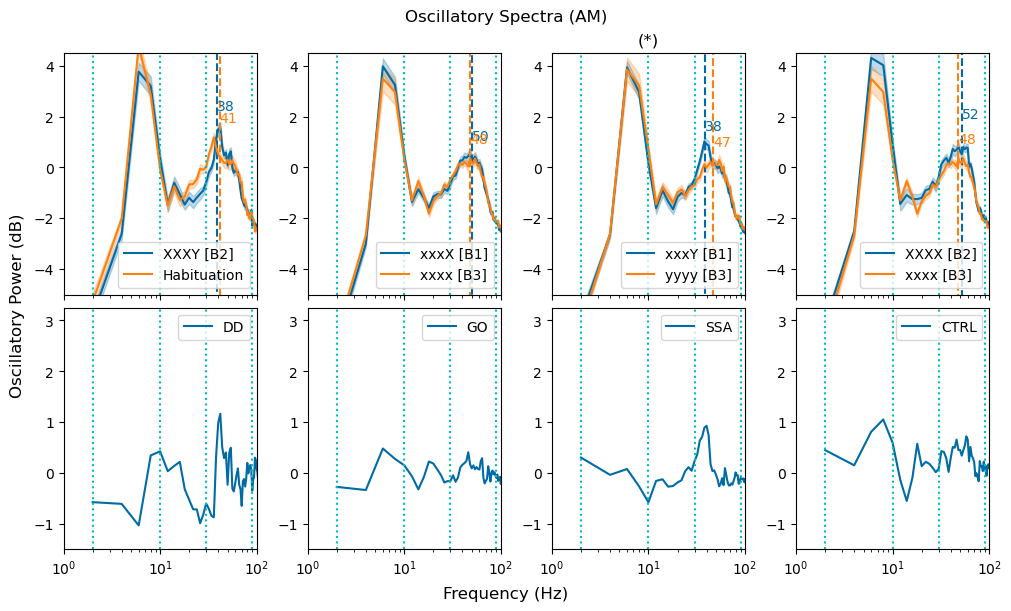

In [33]:
spectrum_trials = collections.defaultdict(lambda: collections.defaultdict(lambda: []))
for cond in CONDITIONS:
    for subject in summaries[cond]:
        for area in oscillatories[cond][subject]:
            spectrum_trials[area][cond].append(oscillatories[cond][subject][area].data.magnitude.mean(axis=(0, -1), keepdims=True))
for area in spectrum_trials:
    for cond in spectrum_trials[area]:
        spectrum_trials[area][cond] = np.concatenate(spectrum_trials[area][cond], axis=-1).squeeze()

for area in anatomical_areas:
    plt.style.use('tableau-colorblind10')
    #               DD, GO, SSA
    # Oddball
    # Control
    # Difference
    fig, axes = plt.subplots(nrows=2, ncols=len(CONTRASTS), sharex=True, sharey=False, layout="constrained", figsize=(10, 6))
    fig.supxlabel("Frequency (Hz)"); fig.supylabel("Oscillatory Power (dB)")
    fig.suptitle(("Oscillatory Spectra (%s)" % AREA_TITLES[area]))
    for col, (contrast, condl, condr) in enumerate(CONTRASTS):
        lines = plotting.plot_sem(oscillatories[condl][subject][area].freqs.magnitude, spectrum_trials[area][condl], ax=axes[0, col], axis=-1, sems=2, label=CONDITION_TITLES[condl])
        color = mcolors.to_rgba(lines[0].get_color(), 1.)
        fpeak, peak_pow = band_max(condl, area, *spectrum.GAMMA_BAND)
        axes[0, col].vlines(fpeak, *axes[0, col].get_ybound(), colors=color, linestyles="dashed")
        axes[0, col].annotate("%d" % round(fpeak), (fpeak.magnitude + 0.005, peak_pow), color=color)

        lines = plotting.plot_sem(oscillatories[condr][subject][area].freqs.magnitude, spectrum_trials[area][condr], ax=axes[0, col], axis=-1, sems=2, label=CONDITION_TITLES[condr])
        color = mcolors.to_rgba(lines[0].get_color(), 1.)
        fpeak, peak_pow = band_max(condr, area, *spectrum.GAMMA_BAND)
        axes[0, col].vlines(fpeak, *axes[0, col].get_ybound(), colors=color, linestyles="dashed")
        axes[0, col].annotate("%d" % round(fpeak), (fpeak.magnitude + 0.005, peak_pow), color=color)

        significance = band_peak_test(condl, condr, area, *spectrum.GAMMA_BAND)
        if significance is not None:
            axes[0, col].set_title("(%s)" % significance)

        for boundary in BAND_BOUNDS:
            axes[0, col].axvline(boundary, color='c', linestyle=':')
        axes[0, col].set_xlim([1, 100]); axes[0, col].set_xscale("log");
        axes[0, col].set_ylim([-5, 4.5])
        axes[0, col].legend()

        axes[1, col].plot(oscillatories[condr][subject][area].freqs.magnitude, spectrum_trials[area][condl].mean(axis=-1) - spectrum_trials[area][condr].mean(axis=-1), label=CONTRAST_TITLES[contrast])
        for boundary in BAND_BOUNDS:
            axes[1, col].axvline(boundary, color='c', linestyle=':')
        axes[1, col].set_xlim([1, 100])
        axes[1, col].legend()
        axes[1, col].set_ylim([-1.5, 3.25])
    plt.savefig("%s_oscillatory_spectra.svg" % AREA_TITLES[area])
    plt.savefig("%s_oscillatory_spectra.png" % AREA_TITLES[area])
    plt.show()

In [34]:
GAMMA_PEAKS = {cond: {area: () for area in anatomical_areas} for cond in CONDITIONS}
GAMMA_PEAKS = collections.defaultdict(lambda: collections.defaultdict(lambda: (30., 90.)))

GAMMA_PEAKS["go_gloexp"]["VISp"] = (31., 74.)
GAMMA_PEAKS["go_gloexp"]["VISl"] = (34., 63.)

GAMMA_PEAKS["go_seqctl"]["VISp"] = (31., 73.)
GAMMA_PEAKS["go_seqctl"]["VISrl"] = (34., 46.)
GAMMA_PEAKS["go_seqctl"]["VISal"] = (32., 73.)
GAMMA_PEAKS["go_seqctl"]["VISpm"] = (45., 57.)
GAMMA_PEAKS["go_seqctl"]["VISam"] = (45., 57.)

GAMMA_PEAKS["lo_gloexp"]["VISp"] = (35., 45.)
GAMMA_PEAKS["lo_gloexp"]["VISl"] = (36., 47.)
GAMMA_PEAKS["lo_gloexp"]["VISrl"] = (35., 47.)
GAMMA_PEAKS["lo_gloexp"]["VISal"] = (32., 44.)
GAMMA_PEAKS["lo_gloexp"]["VISpm"] = (37., 49.)
GAMMA_PEAKS["lo_gloexp"]["VISam"] = (36., 48.)

GAMMA_PEAKS["igo_seqctl"]["VISp"] = (35., 47.)
GAMMA_PEAKS["igo_seqctl"]["VISl"] = (37., 49.)
GAMMA_PEAKS["igo_seqctl"]["VISal"] = (35., 47.)
GAMMA_PEAKS["igo_seqctl"]["VISpm"] = (33., 61.)
GAMMA_PEAKS["igo_seqctl"]["VISam"] = (44., 56.)

GAMMA_PEAKS["lo_rndctl"]["VISp"] = (34., 46.)
GAMMA_PEAKS["lo_rndctl"]["VISl"] = (34., 59.)
GAMMA_PEAKS["lo_rndctl"]["VISrl"] = (36., 46.)
GAMMA_PEAKS["lo_rndctl"]["VISal"] = (34., 44.)
GAMMA_PEAKS["lo_rndctl"]["VISpm"] = (36., 48.)
GAMMA_PEAKS["lo_rndctl"]["VISam"] = (34., 63.)

GAMMA_PEAKS["lonaive"]["VISp"] = (29., 41.)
GAMMA_PEAKS["lonaive"]["VISl"] = (31., 43.)
GAMMA_PEAKS["lonaive"]["VISrl"] = (31., 43.)
GAMMA_PEAKS["lonaive"]["VISal"] = (29., 41.)
GAMMA_PEAKS["lonaive"]["VISam"] = (33., 45.)

In [35]:
subject_gamma_powers = {
    cond: {
        subject: {
            area: oscillatories[cond][subject][area].select_channels(["2/3" in loc for loc in oscillatories[cond][subject][area].channels.location]).band_power(
                GAMMA_PEAKS[cond][area][0] * pq.Hz, GAMMA_PEAKS[cond][area][1] * pq.Hz
            ).mean() for area in summaries[cond][subject].stats
        } for subject in summaries[cond]
    } for cond in CONDITIONS
}

In [36]:
gamma_powers = {cond: {area: [] for area in anatomical_areas} for cond in subject_gamma_powers}
for cond in CONDITIONS:
    for subject in subject_gamma_powers[cond]:
        for area in subject_gamma_powers[cond][subject]:
            if area not in anatomical_areas:
                continue
            gamma_powers[cond][area].append(subject_gamma_powers[cond][subject][area])
    for area in anatomical_areas:
        gamma_powers[cond][area] = np.stack(gamma_powers[cond][area], axis=-1) * spectrum.decibel

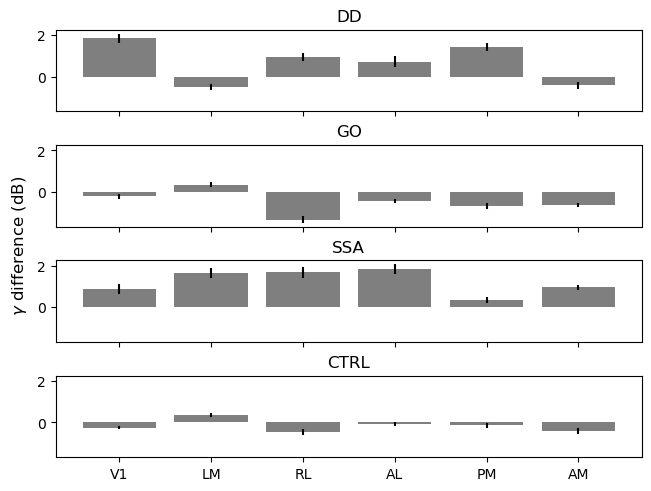

In [37]:
fig, axes = plt.subplots(nrows=len(CONTRASTS), ncols=1, sharex=True, sharey=True, layout="constrained")
fig.supylabel("$\\gamma$ difference (dB)")
for row, (contrast, condl, condr) in enumerate(CONTRASTS):
    gamma_contrasts = {area: gamma_powers[condl][area] - gamma_powers[condr][area] for area in anatomical_areas}
    axes[row].bar(np.arange(len(anatomical_areas)), [gamma_contrasts[area].mean(axis=-1) for area in anatomical_areas],
                  yerr=[2 * gamma_contrasts[area].std(axis=-1) / gamma_contrasts[area].shape[-1] for area in anatomical_areas],
                  color=mcolors.TABLEAU_COLORS['tab:gray'],
                  tick_label=[AREA_TITLES[area] for area in anatomical_areas])
    axes[row].set_title(CONTRAST_TITLES[contrast])

plt.savefig("area_gamma_contrasts.svg")
plt.savefig("area_gamma_contrasts.png")
plt.show()